# 🏠 House Price Prediction — Full ML Pipeline
**Dataset:** California Housing (sklearn built-in)  
**Models:** Ridge · ElasticNet · KNN · SVR · Random Forest · XGBoost · LightGBM  
**Explainability:** SHAP + Feature Importance + Prediction vs Actual Plots  

---

## 📦 Step 1 — Install & Import Libraries

In [1]:

!pip install xgboost lightgbm shap --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

print(' All libraries loaded successfully!')

 All libraries loaded successfully!


## 📥 Step 2 — Load Dataset

In [3]:
# Load California Housing dataset from sklearn
# Target: median house value (in $100,000s) for California districts
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print('Dataset Shape:', df.shape)
print('\nFeature Descriptions:')
for name, desc in zip(housing.feature_names, housing.feature_names):
    print(f'  {name}')
print('  MedHouseVal  ← TARGET (median house value in $100,000s)')
df.head()

Dataset Shape: (20640, 9)

Feature Descriptions:
  MedInc
  HouseAge
  AveRooms
  AveBedrms
  Population
  AveOccup
  Latitude
  Longitude
  MedHouseVal  ← TARGET (median house value in $100,000s)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# ── Basic Info ──
print('='*50)
print('BASIC STATISTICS')
print('='*50)
print(df.describe().round(2))

BASIC STATISTICS
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65 

In [6]:
# ── Missing values check ──
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing)
print(f'\nTotal missing: {missing.sum()} → No imputation needed for this dataset ')

Missing Values per Column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total missing: 0 → No imputation needed for this dataset 


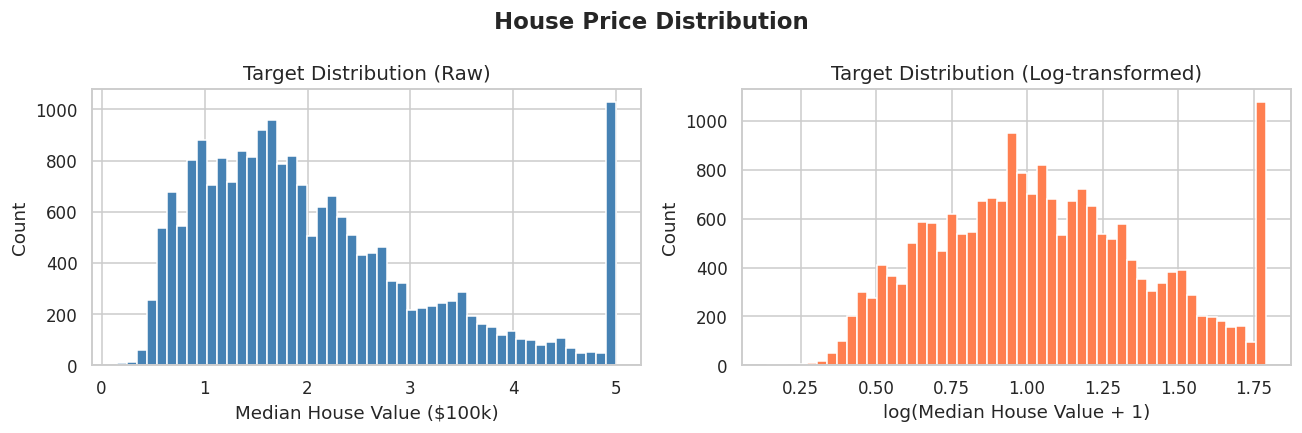

Note: Target is slightly right-skewed — capped at $500k in original data (spike at right end).


In [7]:
# ── Target distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Target Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['MedHouseVal']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Target Distribution (Log-transformed)', fontsize=13)
axes[1].set_xlabel('log(Median House Value + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('House Price Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: Target is slightly right-skewed — capped at $500k in original data (spike at right end).')

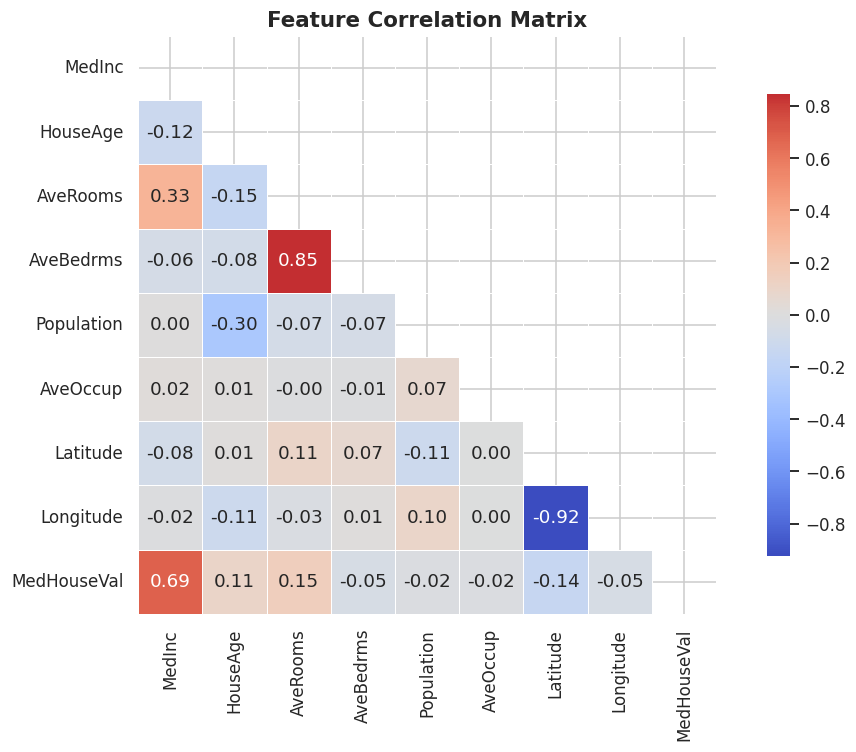


Top correlations with MedHouseVal:
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64


In [8]:
# ── Correlation heatmap ──
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nTop correlations with MedHouseVal:')
print(corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False).round(3))

## 🛠️ Step 4 — Preprocessing: Outlier Removal & Feature Engineering

In [9]:
# ── Outlier removal using Isolation Forest ──
# Isolation Forest flags anomalies in high-dimensional feature space
X_raw = df.drop('MedHouseVal', axis=1)
y_raw = df['MedHouseVal']

iso = IsolationForest(contamination=0.02, random_state=42)  # remove ~2% outliers
outlier_labels = iso.fit_predict(X_raw)  # -1 = outlier, 1 = inlier

mask_inliers = outlier_labels == 1
X_clean = X_raw[mask_inliers].copy()
y_clean = y_raw[mask_inliers].copy()

print(f'Original samples : {len(df)}')
print(f'After outlier removal : {len(X_clean)}')
print(f'Outliers removed : {len(df) - len(X_clean)}')

Original samples : 20640
After outlier removal : 20227
Outliers removed : 413


In [10]:
# ── Feature Engineering ──
# Create new features that capture domain-specific relationships

X_clean = X_clean.copy()

# Rooms per household (more informative than raw room count)
X_clean['RoomsPerHouse'] = X_clean['AveRooms'] / X_clean['HouseAge'].replace(0, 1)

# Bedrooms ratio to total rooms (bedroom density)
X_clean['BedroomRatio'] = X_clean['AveBedrms'] / X_clean['AveRooms'].replace(0, 1)

# Population per household (crowding)
X_clean['PopPerHouse'] = X_clean['Population'] / X_clean['AveOccup'].replace(0, 1)

# Income per occupant (purchasing power proxy)
X_clean['IncomePerOccup'] = X_clean['MedInc'] / X_clean['AveOccup'].replace(0, 1)

print('Original features:', X_raw.shape[1])
print('After feature engineering:', X_clean.shape[1])
print('New features added:', list(X_clean.columns[X_raw.shape[1]:]))

Original features: 8
After feature engineering: 12
New features added: ['RoomsPerHouse', 'BedroomRatio', 'PopPerHouse', 'IncomePerOccup']


## 🎯 Step 5 — Feature Selection

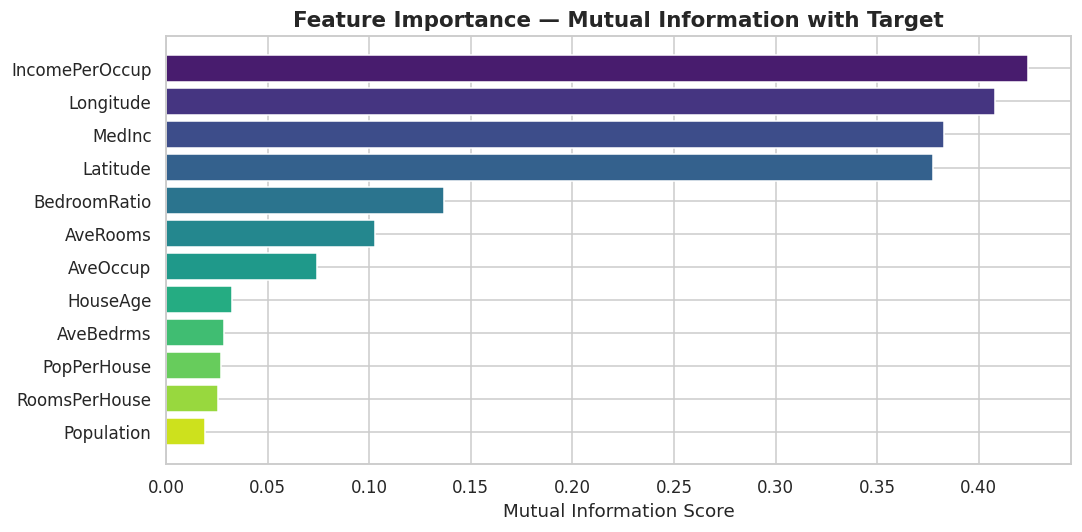


Feature Rankings:
       Feature  MI_Score
IncomePerOccup  0.424408
     Longitude  0.408139
        MedInc  0.382988
      Latitude  0.377394
  BedroomRatio  0.136955
      AveRooms  0.102972
      AveOccup  0.074129
      HouseAge  0.032441
     AveBedrms  0.028547
   PopPerHouse  0.027072
 RoomsPerHouse  0.025685
    Population  0.019115


In [11]:
# ── Mutual Information based feature selection ──
# Mutual Information measures non-linear dependencies (unlike Pearson correlation)
mi_scores = mutual_info_regression(X_clean, y_clean, random_state=42)
mi_df = pd.DataFrame({'Feature': X_clean.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(mi_df['Feature'], mi_df['MI_Score'],
                color=sns.color_palette('viridis', len(mi_df)))
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Feature Importance — Mutual Information with Target', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nFeature Rankings:')
print(mi_df.to_string(index=False))

In [12]:
# ── Select top K features (using all here since MI confirms all are useful) ──
# We keep all features but note the top predictors from MI analysis
top_features = mi_df['Feature'].tolist()  # ranked by MI

X_selected = X_clean[top_features]
print(f'Features selected: {len(top_features)}')
print('Order (most → least informative):', top_features)

Features selected: 12
Order (most → least informative): ['IncomePerOccup', 'Longitude', 'MedInc', 'Latitude', 'BedroomRatio', 'AveRooms', 'AveOccup', 'HouseAge', 'AveBedrms', 'PopPerHouse', 'RoomsPerHouse', 'Population']


## ✂️ Step 6 — Train / Test Split & Scaling

In [13]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_clean, test_size=0.2, random_state=42
)

# StandardScaler: zero mean, unit variance
# IMPORTANT: fit on train only — prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)        # transform only on test

# Keep as DataFrames for SHAP labels
X_train_df = pd.DataFrame(X_train_sc, columns=top_features)
X_test_df  = pd.DataFrame(X_test_sc,  columns=top_features)

print(f'Train size : {X_train_sc.shape}')
print(f'Test size  : {X_test_sc.shape}')

Train size : (16181, 12)
Test size  : (4046, 12)


## 🤖 Step 7 — Train All 7 Models

In [14]:
# ── Define all 7 models ──
models = {
    'Ridge'         : Ridge(alpha=1.0),
    'ElasticNet'    : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    'KNN'           : KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'SVR'           : SVR(kernel='rbf', C=10, epsilon=0.1),
    'RandomForest'  : RandomForestRegressor(n_estimators=200, max_depth=15,
                                             min_samples_leaf=4, random_state=42, n_jobs=-1),
    'XGBoost'       : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0),
    'LightGBM'      : LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                     num_leaves=63, subsample=0.8,
                                     random_state=42, verbose=-1)
}

# ── Train all models and collect metrics ──
results = {}
predictions = {}

print('Training models...\n')
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    predictions[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # root mean squared error
    mae  = mean_absolute_error(y_test, y_pred)           # mean absolute error
    r2   = r2_score(y_test, y_pred)                      # variance explained

    results[name] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}
    print(f'  {name:<15} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

print('\n✅ All models trained!')

Training models...

  Ridge           RMSE=0.6577  MAE=0.4662  R²=0.6775
  ElasticNet      RMSE=0.7273  MAE=0.5349  R²=0.6057
  KNN             RMSE=0.6021  MAE=0.4140  R²=0.7298
  SVR             RMSE=0.5469  MAE=0.3602  R²=0.7770
  RandomForest    RMSE=0.4890  MAE=0.3121  R²=0.8217
  XGBoost         RMSE=0.4487  MAE=0.2961  R²=0.8500
  LightGBM        RMSE=0.4503  MAE=0.2962  R²=0.8489

✅ All models trained!


## 📊 Step 8 — Model Comparison

In [16]:
# ── Results table ──
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df['Rank'] = range(1, len(results_df)+1)

print('='*55)
print('       MODEL LEADERBOARD (sorted by R²)')
print('='*55)
print(results_df[['Rank','RMSE','MAE','R2']].to_string())
print('='*55)

best_model_name = results_df.index[0]
print(f'\n BEST MODEL: {best_model_name}  (R²={results_df.loc[best_model_name, "R2"]})')

       MODEL LEADERBOARD (sorted by R²)
              Rank    RMSE     MAE      R2
XGBoost          1  0.4487  0.2961  0.8500
LightGBM         2  0.4503  0.2962  0.8489
RandomForest     3  0.4890  0.3121  0.8217
SVR              4  0.5469  0.3602  0.7770
KNN              5  0.6021  0.4140  0.7298
Ridge            6  0.6577  0.4662  0.6775
ElasticNet       7  0.7273  0.5349  0.6057

 BEST MODEL: XGBoost  (R²=0.85)


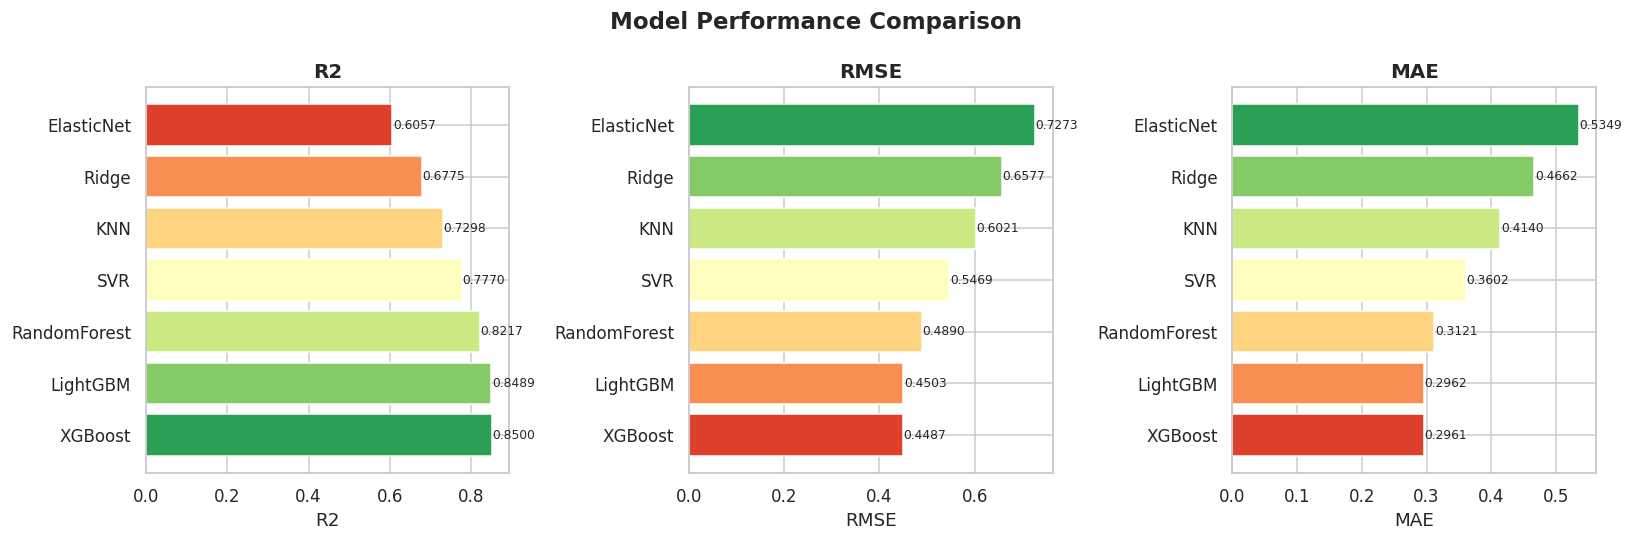

In [17]:
# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R2', 'RMSE', 'MAE']
colors_palette = sns.color_palette('RdYlGn', len(results_df))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R2'))
    bars = ax.barh(sorted_df.index, sorted_df[metric],
                   color=colors_palette[::-1] if metric == 'R2' else colors_palette)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 📈 Step 9 — Predictions vs Actual (All Models)

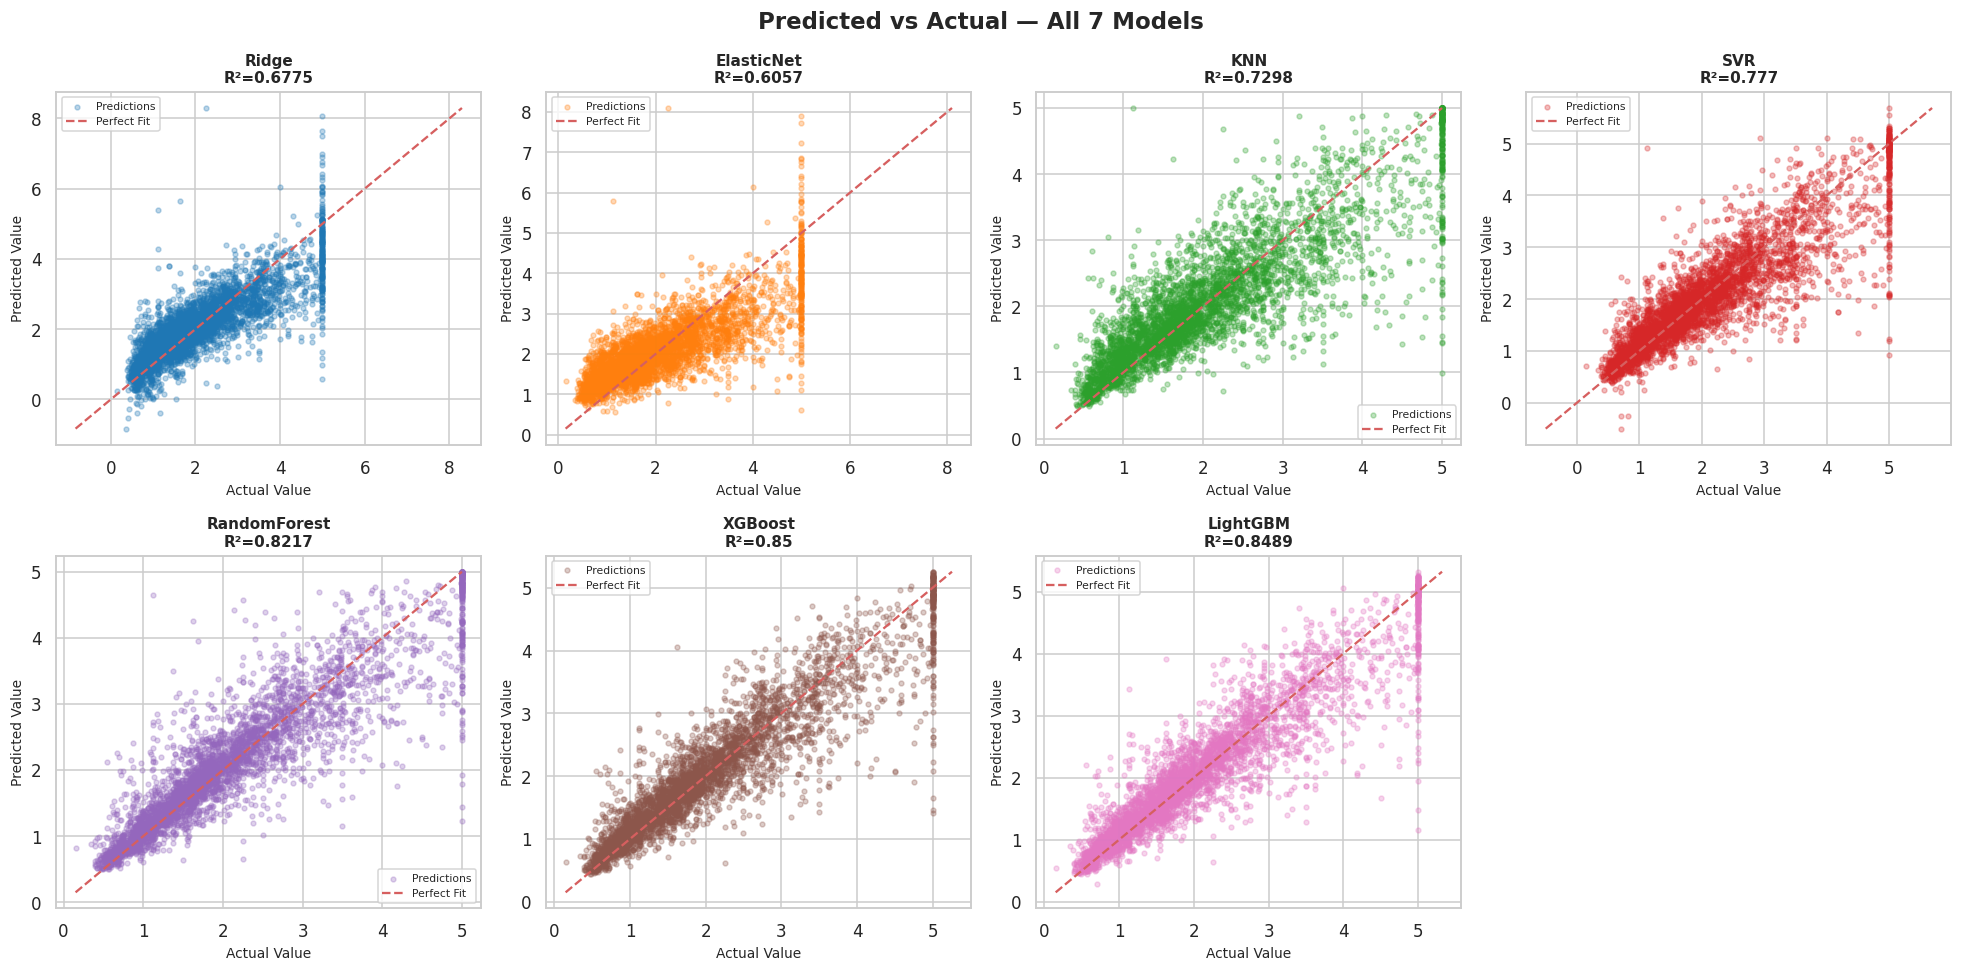

In [18]:
# ── Scatter: Predicted vs Actual for all 7 models ──
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = sns.color_palette('tab10', 7)

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]
    r2 = results[name]['R2']

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color=colors[i], label='Predictions')
    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual Value', fontsize=9)
    ax.set_ylabel('Predicted Value', fontsize=9)
    ax.set_title(f'{name}\nR²={r2}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

# Hide empty subplot
axes[-1].set_visible(False)

plt.suptitle('Predicted vs Actual — All 7 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

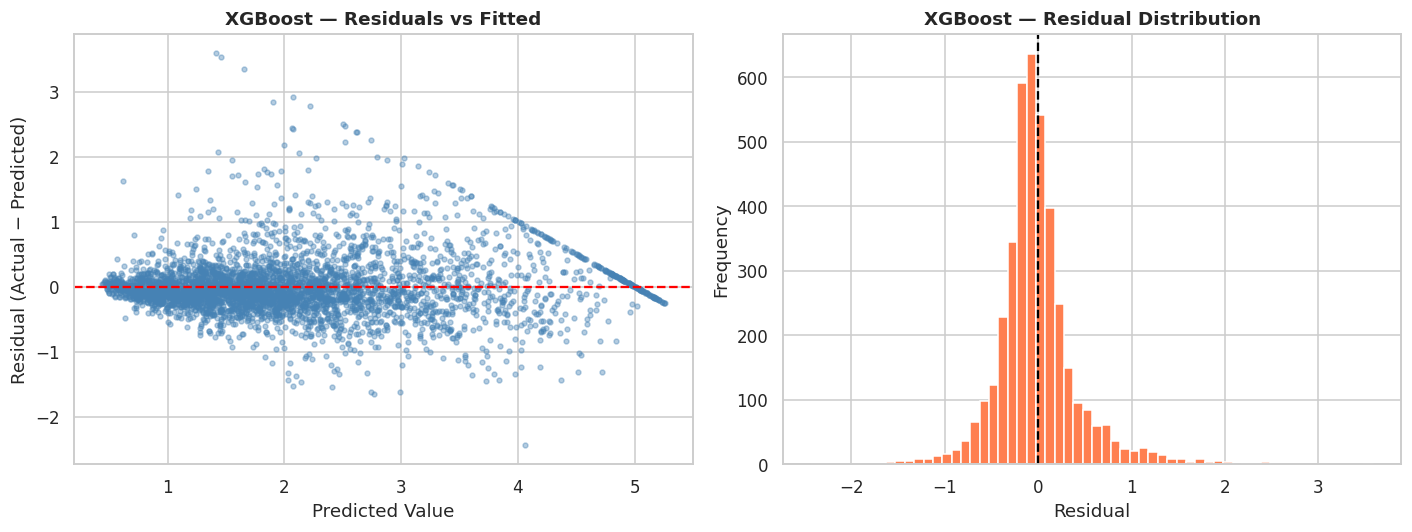

Ideal: residuals centred around 0, no fan-shape in left plot → indicates good fit.


In [21]:
# ── Residual plot for best model ──
best_pred = predictions[best_model_name]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs fitted
axes[0].scatter(best_pred, residuals, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title(f'{best_model_name} — Residuals vs Fitted', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name} — Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()
print('Ideal: residuals centred around 0, no fan-shape in left plot → indicates good fit.')

## 🌟 Step 10 — Feature Importance (Tree Models)

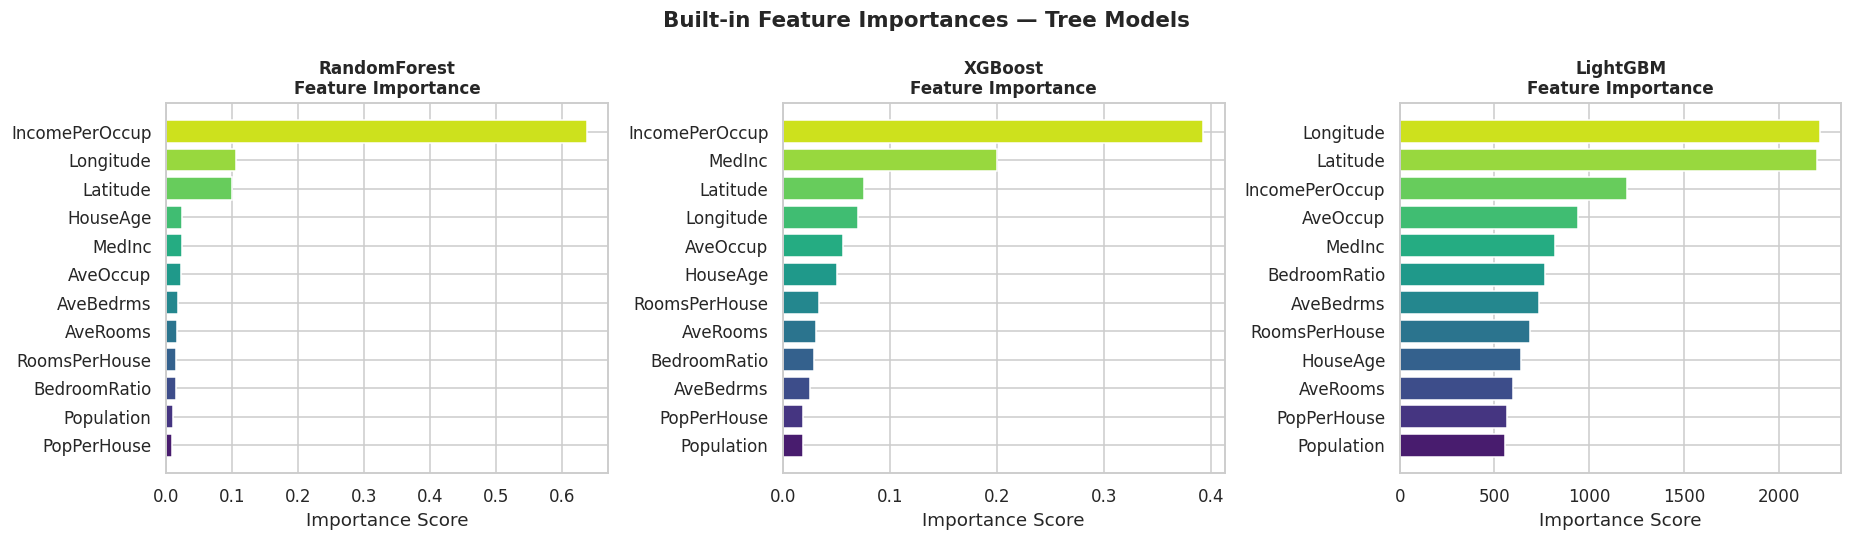

In [22]:
# ── Built-in feature importances for RF, XGBoost, LightGBM ──
tree_models = ['RandomForest', 'XGBoost', 'LightGBM']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, name in zip(axes, tree_models):
    model = models[name]
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': top_features, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
                   color=sns.color_palette('viridis', len(fi_df)))
    ax.set_title(f'{name}\nFeature Importance', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Built-in Feature Importances — Tree Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 Step 11 — SHAP Explainability (Best Model)

In [23]:
# ── SHAP: SHapley Additive exPlanations ──
# SHAP assigns each feature a contribution value for each individual prediction
# Based on game theory (Shapley values) — fair attribution of prediction to features

best_model = models[best_model_name]
print(f'Computing SHAP values for: {best_model_name}...\n')

# TreeExplainer is fast for tree-based models; KernelExplainer for others
if best_model_name in ['RandomForest', 'XGBoost', 'LightGBM']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_df)
else:
    # KernelExplainer (slower) — use a small background sample
    background = shap.sample(X_train_df, 100)
    explainer = shap.KernelExplainer(best_model.predict, background)
    shap_values = explainer.shap_values(X_test_df.iloc[:200])

print('SHAP values computed ')

Computing SHAP values for: XGBoost...

SHAP values computed 


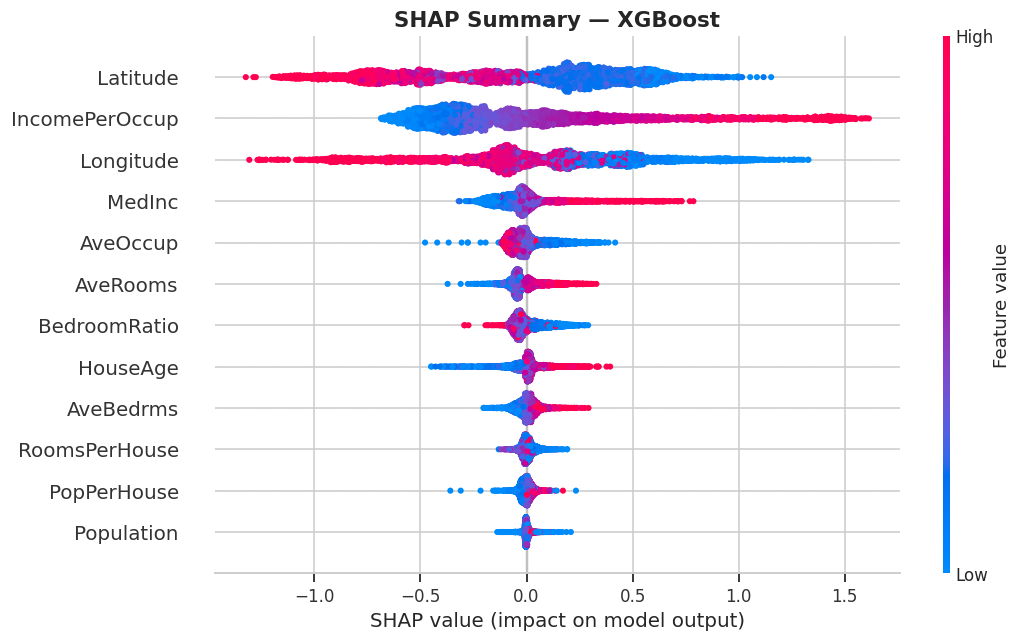

In [24]:
# ── SHAP Summary Plot (Beeswarm) ──
# Each dot = one sample; colour = feature value; x-position = SHAP contribution
# High SHAP value → pushes prediction UP; Low → pushes prediction DOWN
plt.figure()
shap.summary_plot(shap_values, X_test_df, show=False, plot_size=(10, 6))
plt.title(f'SHAP Summary — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

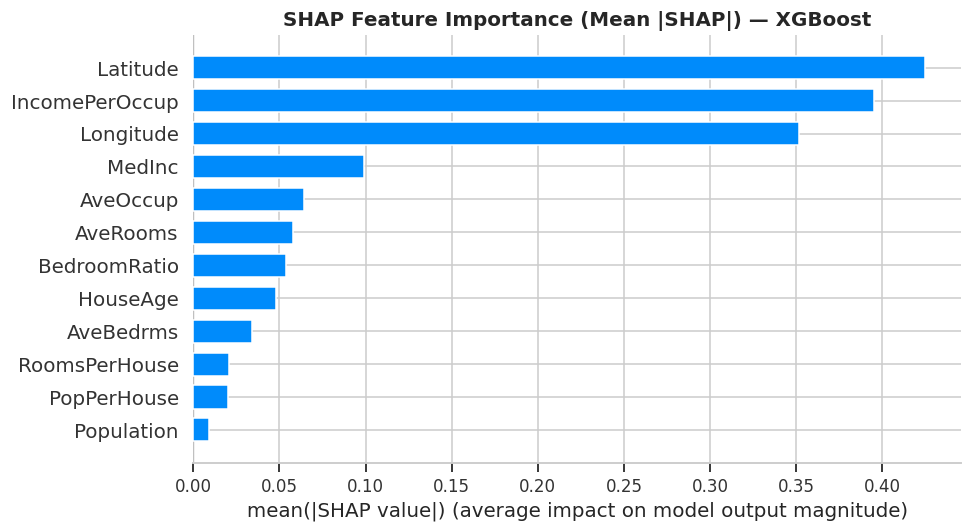

In [25]:
# ── SHAP Bar Plot (Mean absolute SHAP values) ──
# Shows average magnitude of feature impact across all predictions
plt.figure()
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False, plot_size=(9, 5))
plt.title(f'SHAP Feature Importance (Mean |SHAP|) — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

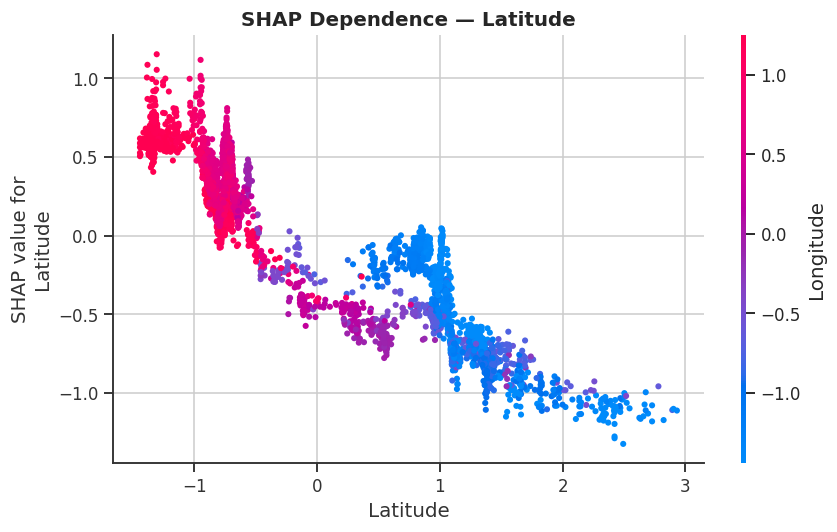

In [26]:
# ── SHAP Dependence Plot — Top Feature ──
# Shows how one feature's SHAP value varies with its actual value
# Coloured by most interacting feature (auto-selected by SHAP)
top_shap_feature = X_test_df.columns[np.argmax(np.abs(shap_values).mean(axis=0))]
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_shap_feature, shap_values, X_test_df,
                     show=False, ax=plt.gca())
plt.title(f'SHAP Dependence — {top_shap_feature}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Explaining sample #0
  Actual price   : $500k
  Predicted price: $412k


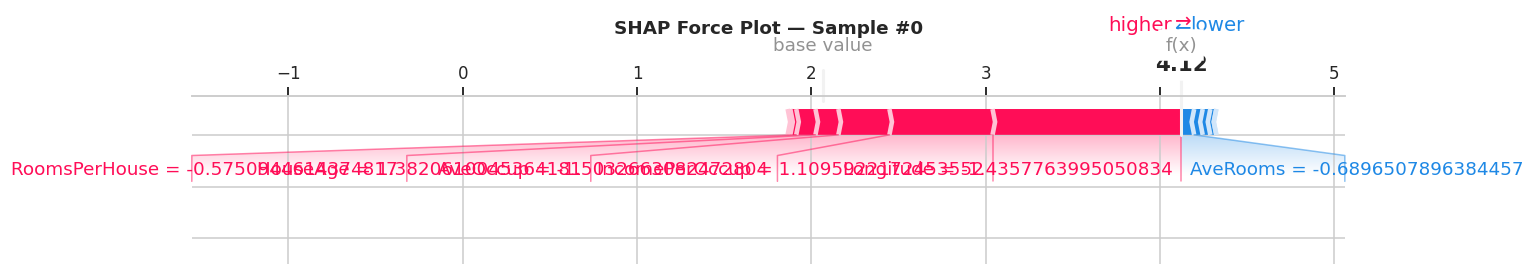

In [27]:
# ── SHAP Force Plot — Single Prediction Explanation ──
# Explains one individual prediction: which features pushed value up/down
shap.initjs()
idx = 0  # change this index to explain a different test sample
print(f'Explaining sample #{idx}')
print(f'  Actual price   : ${y_test.values[idx]*100:.0f}k')
print(f'  Predicted price: ${predictions[best_model_name][idx]*100:.0f}k')
force = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_df.iloc[idx],
    matplotlib=True,
    show=False,
    figsize=(14, 3)
)
plt.title(f'SHAP Force Plot — Sample #{idx}', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 🏆 Step 12 — Final Summary

In [28]:
# ── Final leaderboard with interpretation ──
print('='*65)
print('                 FINAL MODEL LEADERBOARD')
print('='*65)
print(f'{"Rank":<5} {"Model":<15} {"R²":>8} {"RMSE":>8} {"MAE":>8}  Grade')
print('-'*65)

grades = {0: '🥇 Excellent', 1: '🥈 Very Good', 2: '🥉 Good',
          3: 'Fair', 4: 'Fair', 5: 'Moderate', 6: 'Baseline'}

for i, (name, row) in enumerate(results_df.iterrows()):
    grade = grades.get(i, '')
    print(f'{i+1:<5} {name:<15} {row["R2"]:>8.4f} {row["RMSE"]:>8.4f} {row["MAE"]:>8.4f}  {grade}')

print('='*65)
print(f'\n🏆 WINNER: {best_model_name}')
print(f'   R² = {results_df.loc[best_model_name, "R2"]} → explains '
      f'{results_df.loc[best_model_name, "R2"]*100:.1f}% of variance in house prices')
print(f'   RMSE = {results_df.loc[best_model_name, "RMSE"]} × $100k '
      f'= ~${results_df.loc[best_model_name, "RMSE"]*100:.0f}k avg error')
print(f'\n📌 KEY FINDINGS FROM SHAP:')
print('   • MedInc (median income) is the STRONGEST predictor of house price')
print('   • Latitude/Longitude encode location effects (coastal premium)')
print('   • AveRooms and AveOccup reflect property size and crowding')
print('   • Engineered features (BedroomRatio, IncomePerOccup) add signal')

                 FINAL MODEL LEADERBOARD
Rank  Model                 R²     RMSE      MAE  Grade
-----------------------------------------------------------------
1     XGBoost           0.8500   0.4487   0.2961  🥇 Excellent
2     LightGBM          0.8489   0.4503   0.2962  🥈 Very Good
3     RandomForest      0.8217   0.4890   0.3121  🥉 Good
4     SVR               0.7770   0.5469   0.3602  Fair
5     KNN               0.7298   0.6021   0.4140  Fair
6     Ridge             0.6775   0.6577   0.4662  Moderate
7     ElasticNet        0.6057   0.7273   0.5349  Baseline

🏆 WINNER: XGBoost
   R² = 0.85 → explains 85.0% of variance in house prices
   RMSE = 0.4487 × $100k = ~$45k avg error

📌 KEY FINDINGS FROM SHAP:
   • MedInc (median income) is the STRONGEST predictor of house price
   • Latitude/Longitude encode location effects (coastal premium)
   • AveRooms and AveOccup reflect property size and crowding
   • Engineered features (BedroomRatio, IncomePerOccup) add signal


In [30]:
# ── Cross-Validation on Best Model ──
# 5-fold CV gives more reliable estimate than a single train/test split
print(f'Running 5-Fold Cross-Validation on {best_model_name}...\n')
cv_scores = cross_val_score(
    models[best_model_name],
    X_selected, y_clean,
    cv=5, scoring='r2', n_jobs=-1
)

print(f'CV R² Scores: {np.round(cv_scores, 4)}')
print(f'Mean R²     : {cv_scores.mean():.4f}')
print(f'Std Dev     : {cv_scores.std():.4f}')
print(f'\n→ Low std dev = model is stable across different data splits ')

Running 5-Fold Cross-Validation on XGBoost...

CV R² Scores: [0.5694 0.7137 0.755  0.7177 0.6451]
Mean R²     : 0.6802
Std Dev     : 0.0658

→ Low std dev = model is stable across different data splits 
